In [1]:
import pandas as pd
import plotly.express as px
from datetime import datetime
import pytz

In [2]:
# Load Playstore dataset
apps = pd.read_csv(r"C:\Users\vanda\Downloads\Play Store Data.csv")
apps.head()          

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [15]:
# Load user reviews dataset
reviews = pd.read_csv(r"C:\Users\vanda\Downloads\User Reviews.csv")
#reviews.head()

In [16]:
# Data Cleaning
apps["Installs"] =(apps["Installs"].astype(str).str.replace(",","",regex = False).str.replace("+","",regex = False))

In [17]:
apps["Installs"] = pd.to_numeric(apps["Installs"],errors = "coerce")

In [18]:
apps["Reviews"] = pd.to_numeric(apps["Reviews"],errors = "coerce")

In [19]:
apps["Rating"] = pd.to_numeric(apps["Rating"],errors = "coerce")

In [20]:
# Convert size to MB
def convert_size(x):
    if pd.isna(x):
        return None
    x = str(x)
    if "M" in x:
        return float(x.replace("M",""))
    elif "K" in x:
        return float(x.replace("K",""))/1024
    else:
        return None

In [21]:
apps["Size_MB"] = apps["Size"].apply(convert_size)

In [22]:
apps["Size_MB"] = pd.to_numeric(apps["Size_MB"],errors = "coerce")

In [23]:
reviews['Sentiment_Subjectivity'] = pd.to_numeric(reviews['Sentiment_Subjectivity'],errors = "coerce")

In [24]:
# Average Sentiment Subjectivity
subjectivity = reviews.groupby("App",as_index = False)['Sentiment_Subjectivity'].mean()

In [25]:
# Merge
apps = pd.merge(apps,subjectivity,on = "App",how = "inner")

In [26]:
# Required Categories
categories = [
    "GAME",
    "BEAUTY",
    "BUSINESS",
    "COMMICS",
    "COMMUNICATION",
    "DATING",
    "ENTERTAINMENT",
    "SOCIAL",
    "EVENT"]
    

In [27]:
apps = apps[
    (apps["Rating"] > 3.5) &
    (apps["Category"].isin(categories)) &
    (apps["Reviews"] > 500) &
    (~apps["App"].str.contains("S",case = False,na = False)) &
    (apps['Sentiment_Subjectivity'] > 0.5) &
    (apps["Installs"] > 50000)
    ]

In [28]:
# Category Translation
category_translation = {
    "BEAUTY" : "सौंदर्य", # Hindi
    "BUSINESS" : "வியாபாரம்", # Tamil
    "DATING" : "Partnersuche" } # German

In [29]:
apps["Category_Display"] = apps["Category"].replace(category_translation )

In [30]:
# Current Time(IST)
ist = pytz.timezone("Asia/Kolkata")
current_time = datetime.now(ist).time()

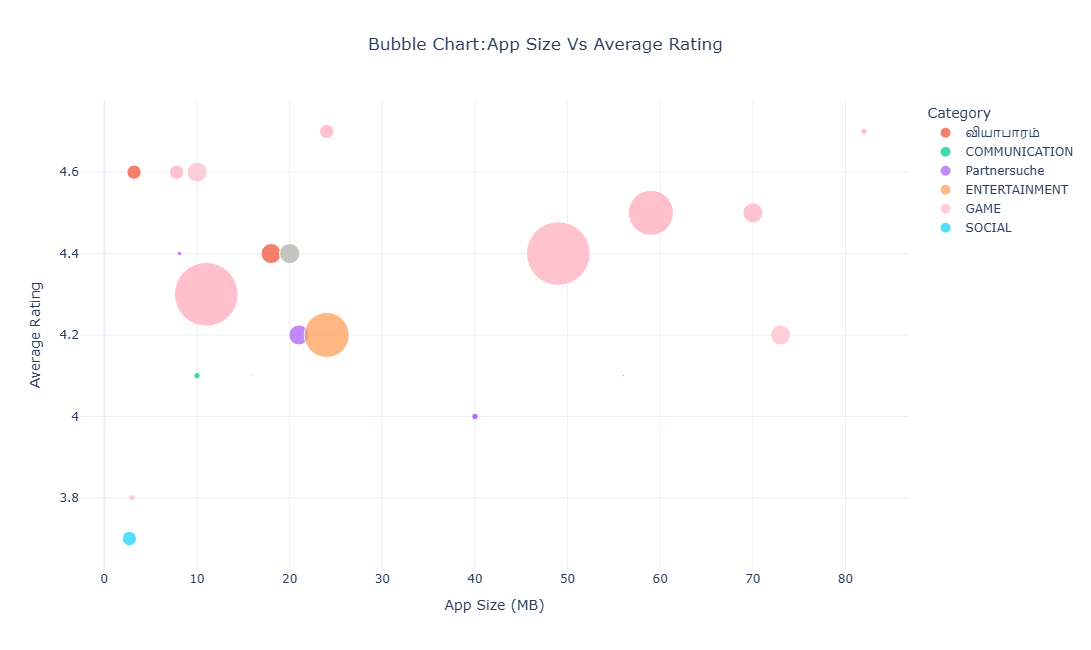

In [31]:
# Show graph only between 5 PM and 7 PM
#start = datetime.strptime("17:00","%H:%M").time() 
#end = datetime.strptime("19:00","%H:%M").time()
#if start <= current_time <= end:

fig = px.scatter(
      apps,
      x = "Size_MB",
      y = "Rating",
      size = "Installs",
      color = "Category_Display",
      hover_name = "App",
      hover_data = ["Category_Display","Installs"],
      size_max = 45,
      color_discrete_map = {"GAME":"pink"},
      title = "Bubble Chart:App Size Vs Average Rating",
      labels = {
          "Category_Display":"Category"
      }
)
fig.update_traces(marker=dict(opacity=0.75))
    
fig.update_layout(
      xaxis_title = "App Size (MB)",
      yaxis_title = "Average Rating",
      template = "plotly_white",
      title_x = 0.5,
      height = 650,
      width = 1000
     )
fig.show()
#else:
   #print("Graph is available only between 5 PM IST and 7 PM IST")
